# Baixando bibliotecas

In [1]:
# Inclusão das bibliotecas usadas no trabalho
import numpy as np
import matplotlib.pyplot as plt
import csv

# Carregando os dados do dataset

In [2]:
# Função para carregar dados do CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])]) # idade, salário
            y.append(int(linha[2]))
    return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("test_dataset1.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primeiras amostras:\n", X[:5], "\nRótulos:", y[:5])

Formato dos dados:  (60, 2) (60,)
Primeiras amostras:
 [[ 0.16133991  0.55611507]
 [ 0.02054845  0.37250535]
 [-0.56956854  0.546234  ]
 [ 0.99591052 -0.12652222]
 [ 0.90825218  0.96756404]] 
Rótulos: [ 1  1  1 -1  1]


# Declaração da classe

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init="random"):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epoch = [] # Armazena o erro a cada época
    
    # Inicializando os pesos de forma customizada
    def _initialize_weights(self, n_features):
        """ Inicializa os pesos de acordo com o método escolhido """
        if self.weight_init == "random":
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == "zeros":
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == "normal":
            self.weights = np.random.randn(n_features) * 0.01 # Pequenos valores gaussianos
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError("Opção inválida para inicialização dos pesos")
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        #self.weights = npzeros(n_features)
        self._initialize_weights(n_features) # Inicializando os pesos dinamicamente
        self.bias = 0
        
        for epoch in range(self.n_epochs):
            errors = 0 # Contador de erros por época

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)

                # Atualização dos pesos se houver erro
                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1 # Incrementa erro se classificação errada

            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epoch.append(errors / n_samples)

            # Parada antecipada se não houver erros
            if errors == 0:
                break

            # Após o treinamento, calcular e exibir estatísticas
            self._print_training_summary(X, y, epoch + 1)

    # Método para exibir a acurácia e pesos finais
    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print("\n===== Resumo do Treinamento =====")
        print(f"Acurácia no conjunto de treino: {accuracy:.2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("===================================")

    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)
    
    # Faz previsões e, se os rótulos forem fornecidos, exibe métricas
    # Coloque esse método (não está no slide)
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)

        # Se y_true for fornecido, calcular métricas de avaliação
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")

        return y_pred

    # Calculando as métricas de predição
    def predict_summary(self, X, y, epochs, phase):
        """ Método para exibir a acurácia, desvio padrão e pesos finais """
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print(f"\n===== Resumo do {phase} ======")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio Padrão dos Pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("====================================")

    # Plota o gráfico da evolução dos erros ao longo das épocas de treinamento.
    def plot_error(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.errors_per_epoch, marker='o', linestyle='-')
        plt.xlabel('Época')
        plt.ylabel('Taxa de erro')
        plt.title('Evolução do erro ao longo das épocas')
        plt.grid()
        plt.show()

# Função para plotar a fronteira de decisão

In [4]:
# Gráfico da 'fronteira' gerado pelo Perceptron
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar o gráfico
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()

# Declaração do método plot_comparison

In [5]:
# Função para plotar lado a lado: dataset e fronteira de decisão
def plot_comparison(X, y, model):
    # Criar uma grade para o plano cartesiano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar os subplots (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1 - Fronteira de Decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")

    # Subplot 2 - Apenas os Dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")

    plt.tight_layout()
    plt.show()

## Treinando o Perceptron com os dados do Dataset 1


===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 95.71%
Número total de épocas: 1
Pesos finais aprendidos: [-0.26023236  0.3095897 ]
Bias final: 0.1

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 97.86%
Número total de épocas: 2
Pesos finais aprendidos: [-0.46382314  0.46462338]
Bias final: 0.2

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 98.57%
Número total de épocas: 3
Pesos finais aprendidos: [-0.54246884  0.50116129]
Bias final: 0.2

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 95.71%
Número total de épocas: 4
Pesos finais aprendidos: [-0.54663043  0.46560493]
Bias final: 0.30000000000000004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 97.14%
Número total de épocas: 5
Pesos finais aprendidos: [-0.56971725  0.51791949]
Bias final: 0.30000000000000004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 94.29%
Número total de épocas: 6
Pesos finais aprendidos: [-0.6635

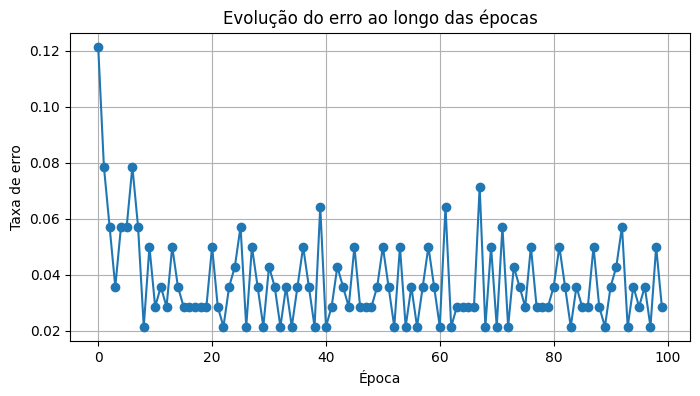

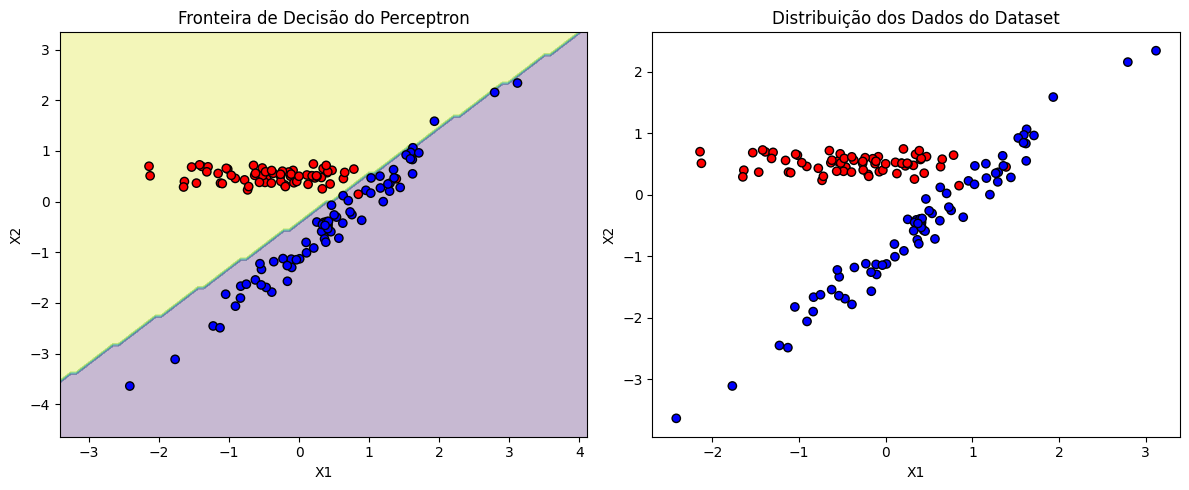

In [6]:
# Dataset 1 - Importando o dataset de treino
train_dataset1 = np.loadtxt("train_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)


## Testando o Perceptron com os dados do Dataset 1


===== Resumo do Teste ======
Acurácia no conjunto de teste: 93.33%
Desvio Padrão dos Pesos: 0.72746
Pesos finais aprendidos: [-0.69997145  0.75494696]
Bias final: 0.30000000000000004


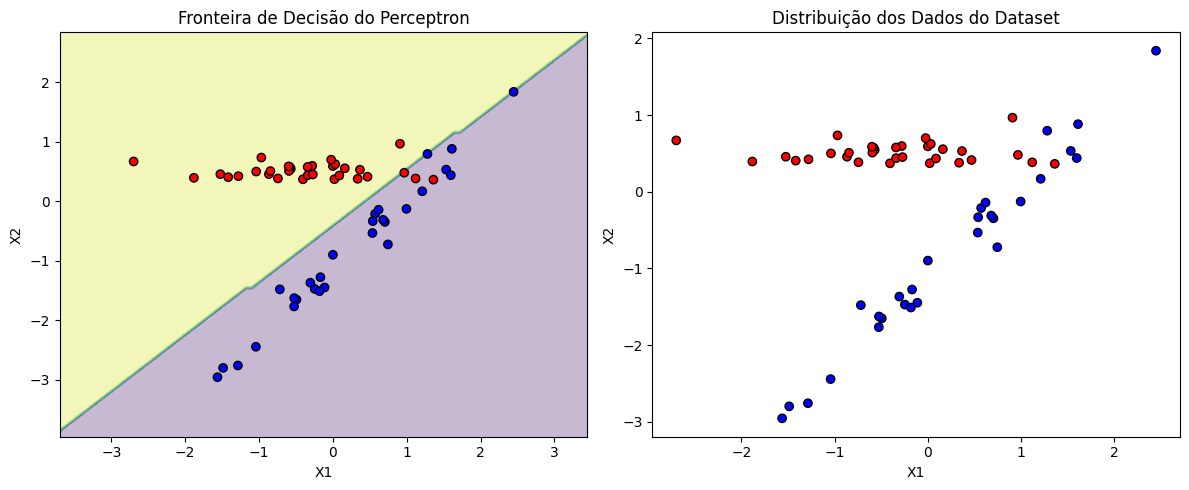

In [7]:
# Dataset 1 - Importando o dataset de treino
test_dataset1 = np.loadtxt("test_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X_test = test_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)


## Treinando o Perceptron com os dados do Dataset 2


===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 49.71%
Número total de épocas: 1
Pesos finais aprendidos: [ 0.09266804 -0.04115787]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.57%
Número total de épocas: 2
Pesos finais aprendidos: [ 0.10027703 -0.05072795]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 47.43%
Número total de épocas: 3
Pesos finais aprendidos: [ 0.08799238 -0.11444168]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.00%
Número total de épocas: 4
Pesos finais aprendidos: [ 0.06829043 -0.06587757]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 49.71%
Número total de épocas: 5
Pesos finais aprendidos: [-0.00252467 -0.03574495]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino

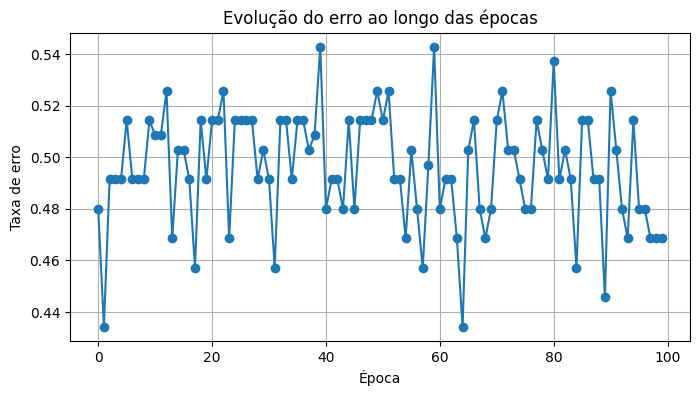

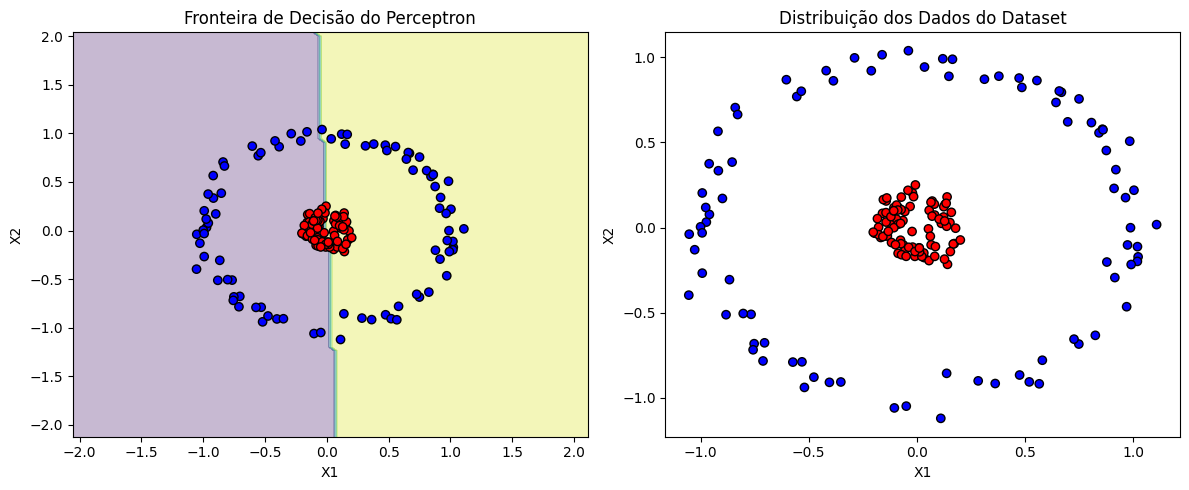

In [8]:
# Dataset 2 - Importando o dataset de treino
train_dataset2 = np.loadtxt("train_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)


## Testando o Perceptron com os dados do Dataset 2


===== Resumo do Teste ======
Acurácia no conjunto de teste: 57.33%
Desvio Padrão dos Pesos: 0.03666
Pesos finais aprendidos: [0.07629326 0.00297251]
Bias final: -2.7755575615628914e-17


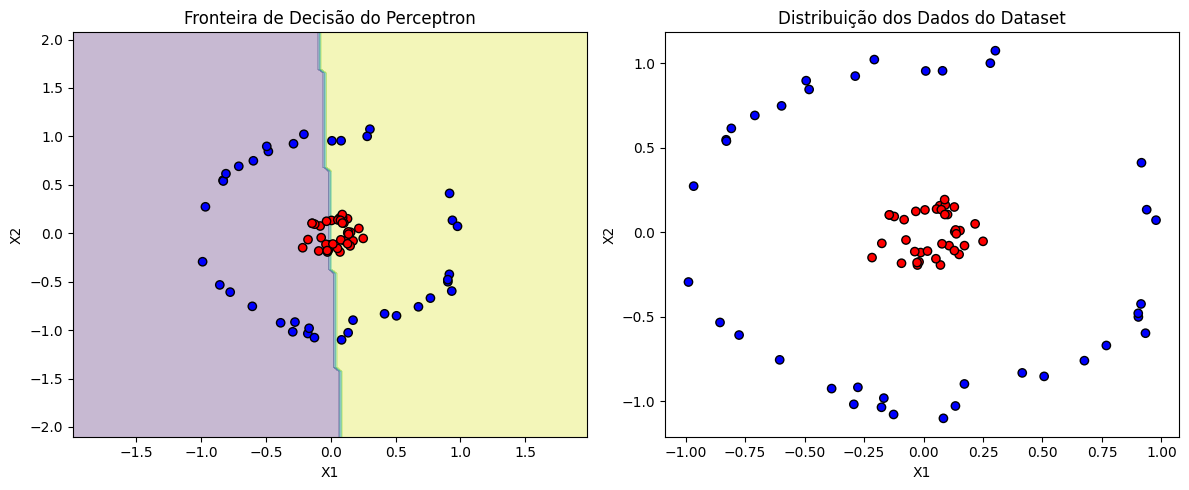

In [9]:
# Dataset 2 - Importando o dataset de treino
test_dataset2 = np.loadtxt("test_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X_test = test_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)


## Treinando o Perceptron com os dados do Dataset 3

Cenário 1 - Tx Treinamento: 0.1 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 93.20%
Número total de épocas: 1
Pesos finais aprendidos: [ 0.00247965  0.01756601  0.16972721 -0.03185629  0.03791316 -0.06799863
  0.10334081  0.13439172 -0.26652432  1.2750913 ]
Bias final: -0.09999999999999998

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 90.48%
Número total de épocas: 2
Pesos finais aprendidos: [-0.1444714  -0.20004988 -0.17393289  0.0419484   0.06438453  0.00431646
  0.15174846  0.39552733 -0.12910209  1.12170215]
Bias final: -0.19999999999999998

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 93.20%
Número total de épocas: 3
Pesos finais aprendidos: [-0.06860559 -0.14926238 -0.20968395 -0.19878964  0.14014588  0.07285258
 -0.01095051  0.18491935 -0.18646637  1.02954897]
Bias final: 2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 91.16%
Número total de épocas: 4
Pesos fina

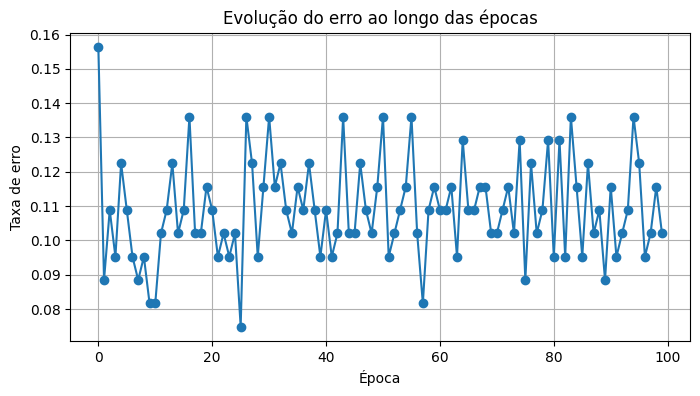


Cenário 2 - Tx Treinamento: 0.1 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 88.44%
Número total de épocas: 1
Pesos finais aprendidos: [ 0.01377479 -0.10510261 -0.00695105 -0.09615151  0.17855232 -0.02939508
  0.02438067  0.39072421 -0.10947557  1.18813207]
Bias final: -0.4

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 93.20%
Número total de épocas: 2
Pesos finais aprendidos: [ 0.04338025 -0.0454112  -0.15766767 -0.15018987  0.08221214 -0.15986117
  0.17898836  0.13439574 -0.22538007  1.06800526]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 89.12%
Número total de épocas: 3
Pesos finais aprendidos: [ 0.00942505 -0.19603486 -0.21792841 -0.31567799  0.23383419 -0.10440335
  0.11264552  0.42050768 -0.09220613  1.0693495 ]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 92.52%
Número total de épocas: 4
Pesos finais aprendid

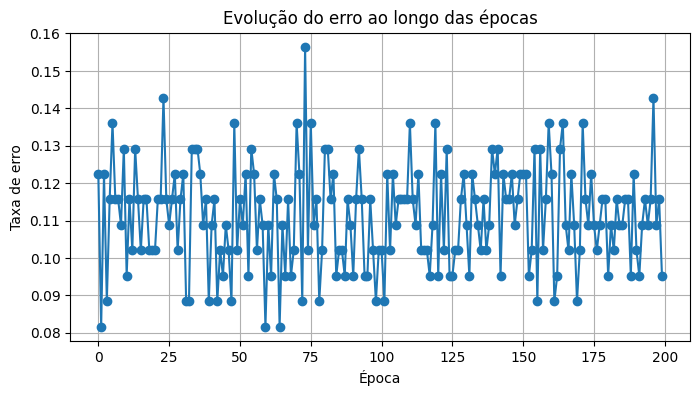


Cenário 3 - Tx Treinamento: 0.001 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 57.82%
Número total de épocas: 1
Pesos finais aprendidos: [0.87065299 0.40951449 0.43131726 0.2471302  0.1965606  0.95651496
 0.15275239 0.72220573 0.57219703 0.33869706]
Bias final: -0.011000000000000003

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 59.18%
Número total de épocas: 2
Pesos finais aprendidos: [0.84350144 0.38551717 0.41605473 0.24225573 0.18876979 0.93115231
 0.14556491 0.70547705 0.53088217 0.39482295]
Bias final: -0.02100000000000001

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 61.90%
Número total de épocas: 3
Pesos finais aprendidos: [0.81548896 0.3630632  0.40152237 0.23953066 0.17928005 0.90454536
 0.13839382 0.68977991 0.49125715 0.44918919]
Bias final: -0.02900000000000002

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 65.99%
Número total de épocas: 4
Pesos finais aprendidos: [0.78699874 0

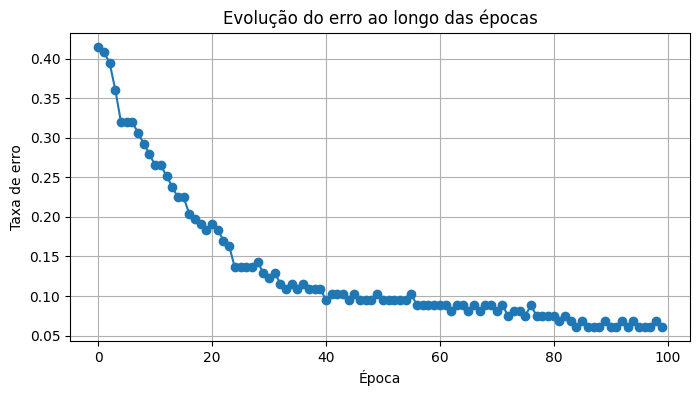


Cenário 4 - Tx Treinamento: 0.001 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 64.63%
Número total de épocas: 1
Pesos finais aprendidos: [0.89367265 0.62200448 0.57849214 0.51375167 0.1695504  0.19128275
 0.41127682 0.89094481 0.90069833 0.81402192]
Bias final: -0.007

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 65.99%
Número total de épocas: 2
Pesos finais aprendidos: [0.87911368 0.5914218  0.56146526 0.50094296 0.1602915  0.1884559
 0.40285692 0.87888109 0.84700295 0.85448962]
Bias final: -0.014000000000000005

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 67.35%
Número total de épocas: 3
Pesos finais aprendidos: [0.86112635 0.56427827 0.54461501 0.48917821 0.15271594 0.18389831
 0.39556256 0.86685222 0.795498   0.89267537]
Bias final: -0.02100000000000001

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 69.39%
Número total de épocas: 4
Pesos finais aprendidos: [0.84187281 0.53920463 0.527

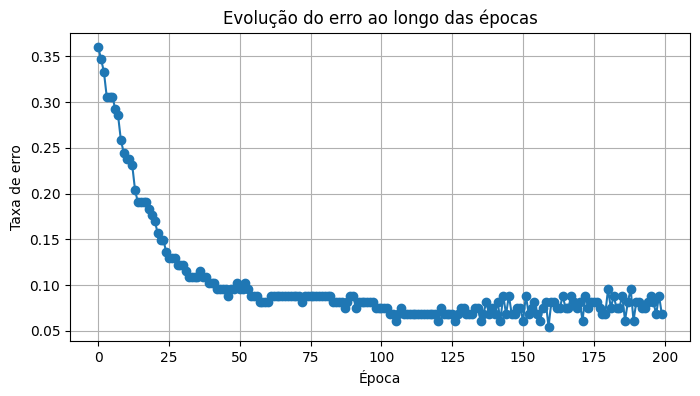


Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 1
Pesos finais aprendidos: [0.84249848 0.58813728 0.85382232 0.94625453 0.59019031 0.64604396
 0.04143344 0.79524783 0.40658527 0.03728527]
Bias final: 0.00020000000000000004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 2
Pesos finais aprendidos: [0.83915306 0.58546118 0.85186828 0.94387435 0.58816798 0.64519228
 0.04172584 0.79358676 0.40329807 0.04509434]
Bias final: 0.0004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 3
Pesos finais aprendidos: [0.83580765 0.58278507 0.84991424 0.94149416 0.58614565 0.64434061
 0.04201824 0.79192569 0.40001087 0.05290341]
Bias final: 0.0006000000000000001

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 4
Pesos finais aprendidos: [0.83246223 0.58010897 0

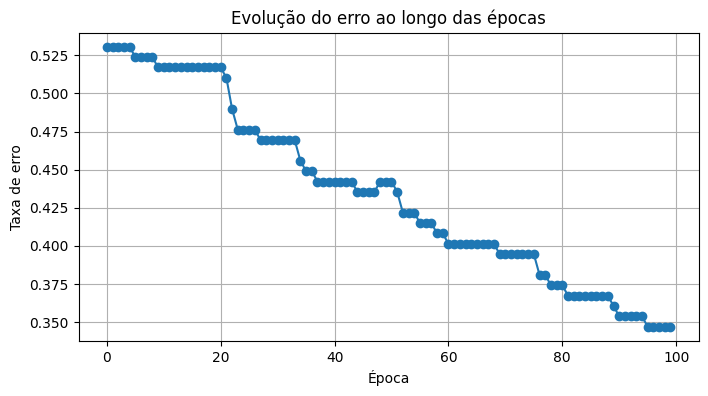


Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 68.71%
Número total de épocas: 1
Pesos finais aprendidos: [0.06643267 0.01064726 0.96109772 0.29813451 0.42127084 0.8265825
 0.17632703 0.73587383 0.9231361  0.88051095]
Bias final: -0.0010000000000000002

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 68.71%
Número total de épocas: 2
Pesos finais aprendidos: [0.06606591 0.00920141 0.95874045 0.297132   0.42012    0.82461672
 0.17551278 0.73515537 0.9187883  0.88375737]
Bias final: -0.0020000000000000005

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 68.71%
Número total de épocas: 3
Pesos finais aprendidos: [0.06569915 0.00775555 0.95638318 0.2961295  0.41896915 0.82265095
 0.17469853 0.73443691 0.91444049 0.88700378]
Bias final: -0.0029999999999999988

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 68.71%
Número total de épocas: 4
Pesos finais aprendidos: [0.06533

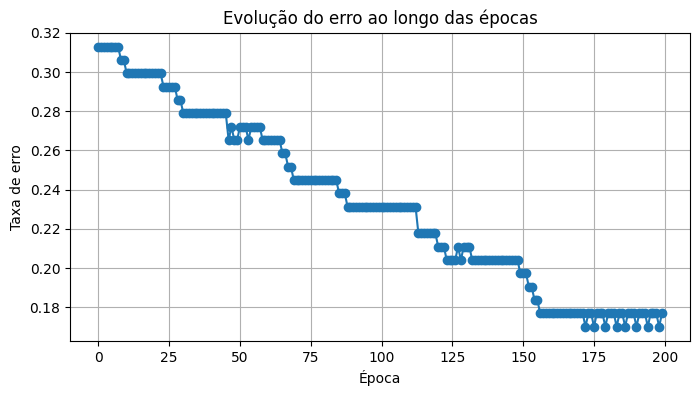

In [10]:
# Dataset 3 - Importando o dataset de treino
train_dataset3 = np.loadtxt("train_dataset3.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset3[:, :-1] # Todas as colunas, exceto a última (10 features)
y = train_dataset3[:, -1] # ÚLtima coluna é o rótulos

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron de acordo com os cenários da tabela
perceptron_cenario_1 = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_cenario_2 = Perceptron(learning_rate=0.1, n_epochs=200)
perceptron_cenario_3 = Perceptron(learning_rate=0.001, n_epochs=100)
perceptron_cenario_4 = Perceptron(learning_rate=0.001, n_epochs=200)
perceptron_cenario_5 = Perceptron(learning_rate=0.0001, n_epochs=100)
perceptron_cenario_6 = Perceptron(learning_rate=0.0001, n_epochs=200)

# --------------------------------------------------------------------
# Cenário 1
print("Cenário 1 - Tx Treinamento: 0.1 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_1.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_1.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 2
print("Cenário 2 - Tx Treinamento: 0.1 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_2.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_2.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 3
print("Cenário 3 - Tx Treinamento: 0.001 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_3.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_3.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 4
print("Cenário 4 - Tx Treinamento: 0.001 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_4.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_4.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 5
print("Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_5.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_5.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 6
print("Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_6.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_6.plot_error()
print("")